In [ ]:
import pandas as pd
import json

## Generate instances

In [ ]:
!python main.py  --generate-instances

In [ ]:
import json

instances = json.load(open('data-storage/domino_tiling/instances/all_instances.json'))
instances

## data generation

In [ ]:
!python main.py  --data-generation

In [ ]:
candidates = json.load(open('data-storage/domino_tiling/candidates/candidate-models.json'))
print(json.dumps(candidates, indent=2))

## Evaluation

#### RQ0: How do common CP evaluation proxies differ from solution-space-based oracle labels?

In [ ]:
!python main.py --num-problems 4  --sat-meta-eval

In [ ]:
# showing the results
results = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-results.csv').fillna("")
results

Also we can assess:
Other data variable instances   ...

In [ ]:
summaries = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-summary.csv').fillna("")
summaries

In [ ]:

df_all.tail()

In [ ]:
import glob
problems = glob.glob("data-storage/*/candidates/sat-meta-eval-results.csv")
df_all = pd.DataFrame()
for pb in problems:
    # print(pb)
    df = pd.read_csv(pb)
    df['problem'] = pb.split("\\")[-3]
    df_all = pd.concat([df_all, df])


print(len(df_all[(df_all["full_space_correct"] == False) & (df_all["sat_only_correct"] == True)]))
print(len(df_all))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── data ─────────────────────────────────────────────────────────────────────
sat_summary = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-summary.csv').fillna('')
sat_results  = pd.read_csv('data-storage/domino_tiling/candidates/sat-meta-eval-results.csv').fillna('')

LABEL_ORDER  = ['equivalent', 'incomplete', 'unsound', 'unsound-incomplete', 'non-executable']
LANG_COLORS  = {'CPMpy': '#1976D2', 'minizinc': '#E64A19'}

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1 – Precision / Recall / F1  by claimed label
# ─────────────────────────────────────────────────────────────────────────────
by_label = sat_summary[sat_summary['view'] == 'by_claimed_label'].copy()
by_label = by_label[by_label['label'].isin(LABEL_ORDER)]
by_label['label'] = pd.Categorical(by_label['label'], categories=LABEL_ORDER, ordered=True)
by_label = by_label.sort_values('label')

fig, ax = plt.subplots(figsize=(10, 4))
x, w = np.arange(len(by_label)), 0.22
ax.bar(x - w, by_label['precision'], w, label='Precision', color='#1565C0', zorder=3)
ax.bar(x,     by_label['recall'],    w, label='Recall',    color='#EF6C00', zorder=3)
ax.bar(x + w, by_label['f1'],        w, label='F1',        color='#2E7D32', zorder=3)
ax.set_xticks(x)
ax.set_xticklabels(by_label['label'], rotation=15, ha='right')
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score')
ax.set_title('RQ0 — Precision / Recall / F1 by Claimed Label\n'
             'sat-only proxy  vs.  full-space oracle', fontsize=11)
ax.axhline(1.0, color='grey', lw=0.8, ls='--', zorder=2)
ax.yaxis.grid(True, ls=':', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('rq0_fig1_prf_by_label.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 2 – sat-only Accuracy:  overall  +  by language
# ─────────────────────────────────────────────────────────────────────────────
overall = sat_summary[sat_summary['view'] == 'overall'].iloc[0]
by_lang = sat_summary[sat_summary['view'] == 'by_language'].copy()

groups   = ['Overall'] + list(by_lang['language'])
accuracy = [float(overall['accuracy'])] + list(by_lang['accuracy'].astype(float))
colors   = ['#455A64'] + [LANG_COLORS.get(l, '#888') for l in by_lang['language']]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(groups, accuracy, color=colors, width=0.45, zorder=3)
ax.set_ylim(0, 1.1)
ax.set_ylabel('sat-only Accuracy')
ax.set_title('RQ0 — SAT-proxy Accuracy\n(overall and by language)', fontsize=11)
ax.yaxis.grid(True, ls=':', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for bar, val in zip(bars, accuracy):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.025,
            f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('rq0_fig2_accuracy_by_language.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 3 – TP / FP / TN / FN stacked bars by claimed label
# ─────────────────────────────────────────────────────────────────────────────
by_label2 = sat_summary[sat_summary['view'] == 'by_claimed_label'].copy()
by_label2 = by_label2[by_label2['label'].isin(LABEL_ORDER)]
by_label2['label'] = pd.Categorical(by_label2['label'], categories=LABEL_ORDER, ordered=True)
by_label2 = by_label2.sort_values('label')

fig, ax = plt.subplots(figsize=(10, 4))
x      = np.arange(len(by_label2))
bottom = np.zeros(len(by_label2))
CONF   = [('tp', '#43A047', 'TP'), ('tn', '#1E88E5', 'TN'),
          ('fp', '#E53935', 'FP'), ('fn', '#FB8C00', 'FN')]
for col, color, lbl in CONF:
    vals = by_label2[col].astype(float).values
    rects = ax.bar(x, vals, bottom=bottom, color=color, label=lbl, zorder=3)
    for rect, v in zip(rects, vals):
        if v > 0:
            ax.text(rect.get_x() + rect.get_width() / 2,
                    rect.get_y() + rect.get_height() / 2,
                    str(int(v)), ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += vals
ax.set_xticks(x)
ax.set_xticklabels(by_label2['label'], rotation=15, ha='right')
ax.set_ylabel('Count')
ax.set_title('RQ0 — Confusion Counts by Claimed Label (sat-only proxy)', fontsize=11)
ax.yaxis.grid(True, ls=':', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()
plt.savefig('rq0_fig3_confusion_by_label.png', dpi=150)
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 4 – P / R / F1 heatmap:  language  x  claimed label
# ─────────────────────────────────────────────────────────────────────────────
by_ll = sat_summary[sat_summary['view'] == 'by_language_label'].copy()
by_ll = by_ll[by_ll['label'].isin(LABEL_ORDER)]
by_ll['label'] = pd.Categorical(by_ll['label'], categories=LABEL_ORDER, ordered=True)

metrics = [('precision', 'Precision'), ('recall', 'Recall'), ('f1', 'F1')]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=True)
for ax, (metric, title) in zip(axes, metrics):
    pivot = by_ll.pivot_table(index='language', columns='label', values=metric)
    pivot = pivot.reindex(columns=LABEL_ORDER)
    im = ax.imshow(pivot.values.astype(float), vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20, ha='right', fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    ax.set_title(title, fontsize=10)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = float(pivot.values[i, j] or 0)
            ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                    fontsize=8, fontweight='bold',
                    color='white' if val > 0.85 else 'black')
fig.colorbar(im, ax=axes.tolist(), shrink=0.8, label='Score')
fig.suptitle('RQ0 — P / R / F1 by Language x Claimed Label', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('rq0_fig4_prf_heatmap_lang_label.png', dpi=150, bbox_inches='tight')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 5 – Oracle vs. sat-proxy agreement per candidate (dot chart)
# ─────────────────────────────────────────────────────────────────────────────
def _agree(row):
    fs = row['full_space_correct'] in (True, 'True')
    so = row['sat_only_correct']   in (True, 'True')
    if fs and so:         return 'Both correct'
    if not fs and not so: return 'Both wrong'
    if fs and not so:     return 'Oracle correct / Proxy wrong'
    return                       'Oracle wrong  / Proxy correct'

evaluable = sat_results[sat_results['exec_status'] == 'ok'].copy()
evaluable['agreement'] = evaluable.apply(_agree, axis=1)
evaluable['label_cat'] = pd.Categorical(
    evaluable['claimed_label'], categories=LABEL_ORDER, ordered=True)
evaluable = evaluable.sort_values(['label_cat', 'language']).reset_index(drop=True)

CAT_ORDER  = ['Both correct', 'Both wrong',
              'Oracle correct / Proxy wrong', 'Oracle wrong  / Proxy correct']
CAT_COLORS = {'Both correct':                 '#43A047',
              'Both wrong':                   '#E53935',
              'Oracle correct / Proxy wrong': '#FB8C00',
              'Oracle wrong  / Proxy correct':'#8E24AA'}

fig, ax = plt.subplots(figsize=(10, 3.8))
y_labels = [f"{r['claimed_label']}  ({r['language']})" for _, r in evaluable.iterrows()]
for i, (_, row) in enumerate(evaluable.iterrows()):
    cat = row['agreement']
    ax.scatter(0.5, i, s=200, color=CAT_COLORS[cat], zorder=3, clip_on=False)
    ax.text(0.65, i, cat, va='center', fontsize=8.5)
ax.set_yticks(range(len(evaluable)))
ax.set_yticklabels(y_labels, fontsize=8.5)
ax.set_xlim(0, 5)
ax.set_xticks([])
ax.set_title('RQ0 — Oracle vs. SAT-proxy Agreement per Candidate\n'
             '(evaluable candidates only)', fontsize=11)
legend_patches = [mpatches.Patch(color=CAT_COLORS[c], label=c) for c in CAT_ORDER]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.9)
ax.spines[['top', 'right', 'bottom']].set_visible(False)
plt.tight_layout()
plt.savefig('rq0_fig5_agreement_per_candidate.png', dpi=150)
plt.show()

print('RQ0 figures saved.')

### llm-as-judge

#### RQ1: How accurately can LLM judges identify CP-specific semantic correctness labels?
#### RQ3: Which context helps judges?

In [ ]:
!python main.py --num-problems 4  --judge --judge-approach reference_free reference_based

In [ ]:
# showing the results

results = pd.read_csv('data-storage/domino_tiling/candidates/judge-results.csv')
results

In [ ]:
summaries = pd.read_csv('data-storage/domino_tiling/candidates/judge-summary.csv').fillna("")
summaries




<span style="color:red"><b>Issue:</b> Reference is always in one language! </span>

#### RQ1 and  RQ3: problem families

In [33]:
judges = pd.read_csv("logs/judge-status.csv")
judges["correct"] = (judges["succeed"] == "yes").astype(int)

def agg(df, group_cols):
    return (
        df.groupby(group_cols)["correct"]
        .agg(correct="sum", total="count")
        .reset_index()
        .assign(accuracy=lambda x: x["correct"] / x["total"])
    )

# Row 0: overall
overall = pd.DataFrame([{
    "view": "overall",
    "correct": judges["correct"].sum(),
    "total": len(judges),
    "accuracy": judges["correct"].mean(),
}])

# Rows 1–4: by judge + language + approach
by_jla = agg(judges, ["judge_llm", "language", "approach"])
by_jla.insert(0, "view", "by_judge_language_approach")

# Rows 5+: by judge + language + approach + label
by_jlal = agg(judges, ["judge_llm", "language", "approach", "label"])
by_jlal.insert(0, "view", "by_judge_language_approach_label")

# Combine
summary = pd.concat([overall, by_jla, by_jlal], ignore_index=True)
display(summary.fillna(""))

,view,correct,total,accuracy,judge_llm,language,approach,label
0,overall,62,94,0.659574,,,,
1,by_judge_language_approach,5,5,1.000000,anthropic/claude-sonnet-4.6,CPMpy,reference_free,
2,by_judge_language_approach,2,4,0.500000,anthropic/claude-sonnet-4.6,minizinc,reference_free,
3,by_judge_language_approach,3,5,0.600000,deepseek/deepseek-chat-v3.1,CPMpy,reference_free,
4,by_judge_language_approach,3,4,0.750000,deepseek/deepseek-chat-v3.1,minizinc,reference_free,
...,...,...,...,...,...,...,...,...
111,by_judge_language_approach_label,1,1,1.000000,qwen/qwen3-coder-next,CPMpy,reference_free,unsound-incomplete
112,by_judge_language_approach_label,1,1,1.000000,qwen/qwen3-coder-next,minizinc,reference_free,equivalent
113,by_judge_language_approach_label,0,1,0.000000,qwen/qwen3-coder-next,minizinc,reference_free,incomplete
114,by_judge_language_approach_label,0,1,0.000000,qwen/qwen3-coder-next,minizinc,reference_free,non-executable


## result preparations

In [73]:
import csv
import sys
import re
import pandas as pd
from IPython.display import display


# judges = pd.read_csv("logs/judge-status.csv")

judges = pd.read_csv("logs/judge-status-all.csv", dtype=str).fillna("")

valid = judges[judges["judgment"] != "judge-error"].copy()
valid = valid[valid["approach"].isin(["reference_based", "reference_free"])]
valid["correct"] = (valid["succeed"] == "yes").astype(int)

def agg(df, group_cols):
    return (
        df.groupby(group_cols, dropna=False)["correct"]
        .agg(correct="sum", total="count")
        .reset_index()
        .assign(accuracy=lambda x: x["correct"] / x["total"])
    )


def judge_table(judge_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (language, approach), lang_df in judge_df.groupby(
        ["language", "approach"], dropna=False
    ):
        rows.append({
            "language": language,
            "approach": approach,
            "breakdown": "overall",
            "label": "",
            "correct": lang_df["correct"].sum(),
            "total": len(lang_df),
            "accuracy": lang_df["correct"].mean(),
        })

        by_label = agg(lang_df, ["label"])
        for _, r in by_label.iterrows():
            rows.append({
                "language": language,
                "approach": approach,
                "breakdown": "by_label",
                "label": r["label"],
                "correct": r["correct"],
                "total": r["total"],
                "accuracy": r["accuracy"],
            })

    out = pd.DataFrame(rows)
    out["_sort"] = out["breakdown"].map({"overall": 0, "by_label": 1})
    return (
        out.sort_values(["language", "approach", "_sort", "label"])
        .drop(columns="_sort")
        .reset_index(drop=True)
    )


def excel_sheet_name(judge_llm: str, used: set[str]) -> str:
    """Excel sheet names: max 31 chars, no []:*?/\\"""
    base = re.sub(r"[\[\]\:\*\?\/\\]", "_", judge_llm)
    base = base.replace("/", "_").replace(":", "_")[:31]

    name = base
    i = 1
    while name in used:
        suffix = f"_{i}"
        name = base[: 31 - len(suffix)] + suffix
        i += 1
    used.add(name)
    return name


# Build all tables
tables_by_judge = {}
for judge_llm in sorted(valid["judge_llm"].unique()):
    judge_df = valid[valid["judge_llm"] == judge_llm]
    table = judge_table(judge_df)
    table["accuracy"] = table["accuracy"].round(3)
    tables_by_judge[judge_llm] = table

    # print(f"\n{'=' * 80}")
    # print(f"Judge: {judge_llm}")
    # print(f"Overall accuracy: {judge_df['correct'].mean():.3f}  "
    #       f"({judge_df['correct'].sum()}/{len(judge_df)})")
    # print(f"{'=' * 80}")
    # display(table)


# Write Excel: one sheet per judge LLM
output_path = "important_files/judge-summary-multi-class.xlsx"
used_sheet_names = set()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    # Optional overview sheet
    overview = agg(valid, ["judge_llm", "language", "approach"])
    overview["accuracy"] = overview["accuracy"].round(3)
    overview.to_excel(writer, sheet_name="overview", index=False)

    for judge_llm, table in tables_by_judge.items():
        sheet = excel_sheet_name(judge_llm, used_sheet_names)
        table.to_excel(writer, sheet_name=sheet, index=False)

print(f"\nSaved Excel file: {output_path}")


Saved Excel file: important_files/judge-summary-multi-class.xlsx


In [74]:
cpmpy_candidate.head(10).fillna(0)

,problem_id,label,precision,recall,f1_measure
0,abbots_puzzle,equivalent,1.0000,1.0,1.0000
1,abbots_puzzle,incomplete,1.0000,0.0,0.0000
2,abbots_puzzle,non-executable,0.0000,0.0,0.0000
3,abbots_puzzle,unsound,0.0833,1.0,0.1538
4,abbots_puzzle,unsound-incomplete,0.0000,0.0,0.0000
5,added_corners,equivalent,1.0000,1.0,1.0000
6,added_corners,incomplete,1.0000,0.5,0.6667
7,added_corners,non-executable,0.0000,0.0,0.0000
8,added_corners,unsound,0.0340,1.0,0.0658
9,added_corners,unsound-incomplete,0.2222,0.5,0.3077


In [75]:
from scipy.stats import kendalltau, pearsonr, spearmanr
from pathlib import Path
import json

REFERENCE_COLS = ["precision", "recall", "f1_measure"]   # ← align with baselines cell



def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

cpmpy_candidate = load_jsonl(Path("important_files/CPJudgeBench_candidates_cpmpy.jsonl"))[["problem_id" , "label"]+REFERENCE_COLS]
cpmpy_candidate = cpmpy_candidate.fillna(0)

language = "CPMpy"
# judges = pd.read_csv("logs/judge-status.csv")
judges = pd.read_csv("logs/judge-status-all.csv", dtype=str).fillna("")
# --- score_reference_based: treat judge score as a metric to correlate with oracle scores ---
srb = (
    judges[
        (judges["approach"] == "score_reference_based") &
        (judges["judgment"] != "judge-error")
    ]
    .copy()
)
srb["judge_score"] = pd.to_numeric(srb["judgment"], errors="coerce")
srb = srb[srb["language"] == language]

merged = srb.merge(
    cpmpy_candidate,
    on=["problem_id", "label"],
    how="inner",
)

rows = []
for judge_llm, grp in merged.groupby("judge_llm"):
    for ref_col in REFERENCE_COLS:                               # ← loop over oracle cols
        sub = grp[["judge_score", ref_col]].dropna()
        n = len(sub)
        if n < 2:
            continue

        tau,  p_tau  = kendalltau(sub["judge_score"], sub[ref_col])
        rs,   p_rs   = spearmanr(sub["judge_score"],  sub[ref_col])
        rp,   p_rp   = pearsonr(sub["judge_score"],   sub[ref_col])

        rows.append({
            "judge_llm":       judge_llm,
            "oracle_score":    ref_col,
            "kendall_tau":     round(float(tau), 4),
            "spearman_rs":     round(float(rs),  4),
            "pearson_r":       round(float(rp),  4),
            "p_value_tau":     round(float(p_tau), 6),
            "p_value_rs":      round(float(p_rs),  6),
            "p_value_pearson": round(float(p_rp),  6),
            "n_samples":       n,
        })

corr_df = pd.DataFrame(rows)
print("=" * 70)
print(f"score_reference_based vs oracle scores ({language}, n_total={len(merged)})")
print("=" * 70)
display(corr_df.sort_values(["judge_llm", "oracle_score"]))   # ← sort by both

out = Path("important_files") / f"judge-summary-score-based-ref-free-{language.lower()}.csv"
corr_df.to_csv(out, index=False)
print(f"Saved: {out}")

score_reference_based vs oracle scores (CPMpy, n_total=1644)


,judge_llm,oracle_score,kendall_tau,spearman_rs,pearson_r,p_value_tau,p_value_rs,p_value_pearson,n_samples
2,anthropic/claude-sonnet-4.6,f1_measure,0.3309,0.3823,0.4211,0.000000,0.000000,0.000000,274
0,anthropic/claude-sonnet-4.6,precision,0.2682,0.3071,0.3124,0.000000,0.000000,0.000000,274
1,anthropic/claude-sonnet-4.6,recall,0.2496,0.2891,0.2887,0.000001,0.000001,0.000001,274
5,google/gemini-2.5-pro,f1_measure,0.3815,0.4212,0.4531,0.000000,0.000000,0.000000,273
3,google/gemini-2.5-pro,precision,0.2477,0.2696,0.2655,0.000001,0.000006,0.000009,273
4,google/gemini-2.5-pro,recall,0.2951,0.3316,0.3217,0.000000,0.000000,0.000000,273
8,meta-llama/llama-4-scout,f1_measure,0.0936,0.1074,0.1265,0.056431,0.076032,0.036356,274
6,meta-llama/llama-4-scout,precision,0.0039,0.0045,0.0267,0.938192,0.941219,0.660331,274
7,meta-llama/llama-4-scout,recall,0.0223,0.0242,0.0198,0.660264,0.689886,0.744095,274
11,openai/gpt-4o-mini,f1_measure,0.1528,0.1822,0.2063,0.002160,0.002469,0.000589,274


Saved: important_files\judge-summary-score-based-ref-free-cpmpy.csv


In [76]:
import json
import re
from pathlib import Path

import pandas as pd
from IPython.display import display
from scipy.stats import kendalltau, pearsonr, spearmanr


def agg(df, group_cols):
    return (
        df.groupby(group_cols, dropna=False)["correct"]
        .agg(correct="sum", total="count")
        .reset_index()
        .assign(accuracy=lambda x: x["correct"] / x["total"])
    )

def judge_table(judge_df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (lang, approach), lang_df in judge_df.groupby(
        ["language", "approach"], dropna=False
    ):
        rows.append({
            "language": lang,
            "approach": approach,
            "breakdown": "overall",
            "label": "",
            "correct": lang_df["correct"].sum(),
            "total": len(lang_df),
            "accuracy": lang_df["correct"].mean(),
        })

        by_label = agg(lang_df, ["label"])
        for _, r in by_label.iterrows():
            rows.append({
                "language": lang,
                "approach": approach,
                "breakdown": "by_label",
                "label": r["label"],
                "correct": r["correct"],
                "total": r["total"],
                "accuracy": r["accuracy"],
            })

    out = pd.DataFrame(rows)
    out["_sort"] = out["breakdown"].map({"overall": 0, "by_label": 1})
    return (
        out.sort_values(["language", "approach", "_sort", "label"])
        .drop(columns="_sort")
        .reset_index(drop=True)
    )

def excel_sheet_name(judge_llm: str, used: set[str]) -> str:
    """Excel sheet names: max 31 chars, no []:*?/\\"""
    base = re.sub(r"[\[\]\:\*\?\/\\]", "_", judge_llm)
    base = base.replace("/", "_").replace(":", "_")[:31]

    name = base
    i = 1
    while name in used:
        suffix = f"_{i}"
        name = base[: 31 - len(suffix)] + suffix
        i += 1
    used.add(name)
    return name

# ---------------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------------
# judges = pd.read_csv("logs/judge-status.csv")

judges = pd.read_csv("logs/judge-status-all.csv", dtype=str).fillna("")

valid = judges[
    (judges["approach"] == "binary_reference_free") &
    (judges["judgment"].isin(["correct", "incorrect"]))
].copy()
valid["correct"] = (valid["succeed"] == "yes").astype(int)

print(f"binary_reference_free rows: {len(valid)}")
print(f"judge LLMs: {sorted(valid['judge_llm'].unique())}")

# ---------------------------------------------------------------------------
# Part 1: accuracy tables -> Excel (same structure as multi-class cell)
# ---------------------------------------------------------------------------
tables_by_judge = {}
for judge_llm in sorted(valid["judge_llm"].unique()):
    judge_df = valid[valid["judge_llm"] == judge_llm]
    table = judge_table(judge_df)
    table["accuracy"] = table["accuracy"].round(3)
    tables_by_judge[judge_llm] = table

    print(f"\n{'=' * 80}")
    print(f"Judge: {judge_llm}")
    print(
        f"Overall accuracy: {judge_df['correct'].mean():.3f}  "
        f"({judge_df['correct'].sum()}/{len(judge_df)})"
    )
    print(f"{'=' * 80}")
    display(table)

output_path = "important_files/judge-summary-binary-ref-free.xlsx"
used_sheet_names = set()

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    overview = agg(valid, ["judge_llm", "language", "approach"])
    overview["accuracy"] = overview["accuracy"].round(3)
    overview.to_excel(writer, sheet_name="overview", index=False)

    for judge_llm, table in tables_by_judge.items():
        sheet = excel_sheet_name(judge_llm, used_sheet_names)
        table.to_excel(writer, sheet_name=sheet, index=False)

print(f"\nSaved Excel file: {output_path}")


binary_reference_free rows: 2725
judge LLMs: ['anthropic/claude-sonnet-4.6', 'google/gemini-2.5-pro', 'meta-llama/llama-4-scout', 'openai/gpt-4o-mini', 'qwen/qwen3-32b', 'qwen/qwen3-coder-next']

Judge: anthropic/claude-sonnet-4.6
Overall accuracy: 0.751  (346/461)


,language,approach,breakdown,label,correct,total,accuracy
0,CPMpy,binary_reference_free,overall,,220,282,0.780
1,CPMpy,binary_reference_free,by_label,equivalent,44,56,0.786
2,CPMpy,binary_reference_free,by_label,incomplete,47,64,0.734
3,CPMpy,binary_reference_free,by_label,non-executable,39,64,0.609
4,CPMpy,binary_reference_free,by_label,unsound,42,44,0.955
5,CPMpy,binary_reference_free,by_label,unsound-incomplete,48,54,0.889
6,minizinc,binary_reference_free,overall,,126,179,0.704
7,minizinc,binary_reference_free,by_label,equivalent,25,27,0.926
8,minizinc,binary_reference_free,by_label,incomplete,28,37,0.757
9,minizinc,binary_reference_free,by_label,non-executable,37,76,0.487



Judge: google/gemini-2.5-pro
Overall accuracy: 0.735  (336/457)


,language,approach,breakdown,label,correct,total,accuracy
0,CPMpy,binary_reference_free,overall,,211,281,0.751
1,CPMpy,binary_reference_free,by_label,equivalent,42,56,0.750
2,CPMpy,binary_reference_free,by_label,incomplete,46,63,0.730
3,CPMpy,binary_reference_free,by_label,non-executable,34,64,0.531
4,CPMpy,binary_reference_free,by_label,unsound,41,44,0.932
5,CPMpy,binary_reference_free,by_label,unsound-incomplete,48,54,0.889
6,minizinc,binary_reference_free,overall,,125,176,0.710
7,minizinc,binary_reference_free,by_label,equivalent,25,27,0.926
8,minizinc,binary_reference_free,by_label,incomplete,28,35,0.800
9,minizinc,binary_reference_free,by_label,non-executable,35,75,0.467



Judge: meta-llama/llama-4-scout
Overall accuracy: 0.691  (315/456)


...


Judge: qwen/qwen3-32b
Overall accuracy: 0.730  (325/445)


,language,approach,breakdown,label,correct,total,accuracy
0,CPMpy,binary_reference_free,overall,,203,273,0.744
1,CPMpy,binary_reference_free,by_label,equivalent,32,54,0.593
2,CPMpy,binary_reference_free,by_label,incomplete,51,62,0.823
3,CPMpy,binary_reference_free,by_label,non-executable,39,62,0.629
4,CPMpy,binary_reference_free,by_label,unsound,37,42,0.881
5,CPMpy,binary_reference_free,by_label,unsound-incomplete,44,53,0.830
6,minizinc,binary_reference_free,overall,,122,172,0.709
7,minizinc,binary_reference_free,by_label,equivalent,19,26,0.731
8,minizinc,binary_reference_free,by_label,incomplete,26,35,0.743
9,minizinc,binary_reference_free,by_label,non-executable,43,74,0.581



Judge: qwen/qwen3-coder-next
Overall accuracy: 0.807  (359/445)


,language,approach,breakdown,label,correct,total,accuracy
0,CPMpy,binary_reference_free,overall,,223,273,0.817
1,CPMpy,binary_reference_free,by_label,equivalent,14,54,0.259
2,CPMpy,binary_reference_free,by_label,incomplete,61,62,0.984
3,CPMpy,binary_reference_free,by_label,non-executable,54,62,0.871
4,CPMpy,binary_reference_free,by_label,unsound,42,42,1.000
5,CPMpy,binary_reference_free,by_label,unsound-incomplete,52,53,0.981
6,minizinc,binary_reference_free,overall,,136,172,0.791
7,minizinc,binary_reference_free,by_label,equivalent,10,26,0.385
8,minizinc,binary_reference_free,by_label,incomplete,31,35,0.886
9,minizinc,binary_reference_free,by_label,non-executable,61,74,0.824



Saved Excel file: important_files/judge-summary-binary-ref-free.xlsx


## Paper 2

#### RQ2: Can LLM judges correctly prefer candidates that are semantically closer to the reference solution space?

Prompt: """
You are an expert CP model judge.
Compare the two candidate models below and decide which better solves the problem.

Allowed decisions:
  "A"   : Candidate A is clearly better (more correct, more complete, or more sound).
  "B"   : Candidate B is clearly better.
  "tie" : Both are equally good or equally flawed; no meaningful difference.

Output format (STRICT JSON only):
{{"winner": "<A|B|tie>", "confidence": <0..1>, "rationale": "<1-3 short sentences>"}}

Problem description:
{context.problem_description}

Candidate A ({language}):
{code_a}

Candidate B ({language}):
{code_b}
"""

In [ ]:
!python main.py --pairwise-judge

In [ ]:
results = pd.read_csv('data-storage/domino_tiling/candidates/pairwise-results.csv')
results

Which pairs?
different language of pairs?
different generator llm of pairs?


#### RQ4: How robust are LLM judges to variations in evaluation conditions?

#### RQ5: Is the benchmark useful for generation workflows?
OR
RQ5: Can LLM judge's scores and feedback improve candidate CP model generation workflows?


for next paper ?

In [ ]:
from pathlib import Path
from src.config import contexts_from_jsonl

contexts = contexts_from_jsonl(
    Path("extra_files/dcp-bench-open.jsonl"),
    num_problems=4,
)

for ctx in contexts:
    print(f"{'='*60}")
    print(f"  Problem ID : {ctx.targeted_id}")
    print(f"{'='*60}")
    print(f"\n[Description]\n{ctx.problem_description}")
    print(f"\n[Reference CP Model]\n{ctx.reference_cp_model}")
    if ctx.data_instances:
        print(f"\n[Data Instances] ({len(ctx.data_instances)} total)")
        for i, inst in enumerate(ctx.data_instances, 1):
            print(f"  Instance {i}: {inst}")
    else:
        print(f"\n[Data Instances] None")
    print()


# post processing to generate results

In [ ]:
import json
import pandas as pd

In [26]:
!python analyze_benchmark_construction.py

Wrote extra_files\preprocessed\data_generation_attempts.csv (2315 rows)

Target slots: 827 (522 succeeded, 305 failed)
Capture modes: direct=319, opportunistic=203, failed=305
Attempts: 2315 total, 319 label matches

By language (target slots):
          total  succeeded  failed
language                          
CPMpy       410        328      82
minizinc    417        194     223

By target label (target slots):
                    total  succeeded  failed
target_label                                
equivalent            169         88      81
incomplete            165        114      51
non-executable        164        159       5
unsound               165         77      88
unsound-incomplete    164         84      80


In [28]:
import pandas as pd
from analyze_benchmark_construction import build_construction_summary_table

attempts_df = pd.read_csv("extra_files/preprocessed/data_generation_attempts.csv")
construction_summary = build_construction_summary_table(attempts_df)
construction_summary

,group,total_attempts,succeeded_targets,failed_targets,success_rate,opportunistic,succeed_first_attempt,failed_after_5_attempts,avg_num_attempts,median_num_attempts
0,total,2315,522,305,0.6312,203,357,305,2.86,2.0
1,CPMpy,873,328,82,0.8000,93,235,82,2.20,1.0
2,minizinc,1442,194,223,0.4652,110,122,223,3.51,5.0
3,CPMpy / equivalent,172,60,22,0.7317,2,43,22,2.39,1.0
4,CPMpy / incomplete,129,76,6,0.9268,28,59,6,1.62,1.0
5,CPMpy / non-executable,128,77,5,0.9390,29,61,5,1.56,1.0
6,CPMpy / unsound,228,55,27,0.6707,6,35,27,2.82,2.0
7,CPMpy / unsound-incomplete,216,60,22,0.7317,28,37,22,2.63,2.0
8,minizinc / equivalent,346,28,59,0.3218,2,11,59,4.08,5.0
9,minizinc / incomplete,306,38,45,0.4578,18,13,45,3.86,5.0


In [ ]:
benchmark_status_df = pd.read_csv("logs/benchmark-status.csv")
benchmark_status_df.head()

In [ ]:
languages = benchmark_status_df["language"].unique()

for language in languages:
    count = len(benchmark_status_df[benchmark_status_df["language"] == language])
    print(f"{language}: {count} problems")

In [ ]:
for language in languages:
    candidates = benchmark_status_df[
        (benchmark_status_df["language"] == language)
        & (benchmark_status_df["succeed"] == "yes")
    ]
    print(f"\nLen Candidates for {language}:")
    print(len(candidates))
    

In [20]:
from pathlib import Path
import json
import pandas as pd
from src.config import load_jsonl
from src.executors import instance_to_dict

# --- config ---
DATA_ROOT = Path("data-storage")
DCP_BENCH_OPEN_PATH = Path("extra_files/dcp-bench-open.jsonl")
OUT_DIR = Path("important_files")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- helpers ---
def to_int_or_none(val):
    if pd.isna(val) or val == "":
        return None
    return int(val)

def solution_space_metrics(ref_size, cand_size, fp, fn):
    ref_size = to_int_or_none(ref_size)
    cand_size = to_int_or_none(cand_size)
    fp = to_int_or_none(fp)
    fn = to_int_or_none(fn)

    if None in (ref_size, cand_size, fp, fn):
        return None, None, None

    tp = ref_size - fn  # same as cand_size - fp
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    if tp==0 and fp==0:
        precision=1
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )
    return round(precision, 4), round(recall, 4), round(f1, 4)

def load_candidate_code(problem_id, generator_llm, language, label):
    path = DATA_ROOT / problem_id / "candidates" / "candidate-models.json"
    if not path.exists():
        return None
    payload = json.loads(path.read_text(encoding="utf-8"))
    return payload.get(generator_llm, {}).get(language, {}).get(label, {}).get("code")



def get_generated_instances(problem_id):
    path = DATA_ROOT / problem_id / "instances" / "all_instances.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return None

# --- load problem metadata once ---
problems_by_id = {p["id"]: p for p in load_jsonl(DCP_BENCH_OPEN_PATH)}

# --- build one jsonl per language ---
for language in languages:
    candidates = benchmark_status_df[
        (benchmark_status_df["language"] == language)
        & (benchmark_status_df["succeed"] == "yes")
    ].copy()

    print(f"\nLen Candidates for {language}: {len(candidates)}")

    records = []
    missing_code = []

    for _, row in candidates.iterrows():
        problem_id = row["problem_id"]
        label = row["target_label"]
        generator_llm = row["generator_llm"]

        problem = problems_by_id.get(problem_id)
        if problem is None:
            continue

        candidate_code = load_candidate_code(problem_id, generator_llm, language, label)
        if candidate_code is None:
            missing_code.append((problem_id, generator_llm, language, label))
            continue

        precision, recall, f1 = solution_space_metrics(
            row["reference_space_size"],
            row["candidate_space_size"],
            row["fp"],
            row["fn"],
        )

        record = {
            "problem_id": problem_id,
            "label": label,
            "generator_llm": generator_llm,
            "example_instance" : problem.get("example_instance", ""),
            "instances": problem.get("instances", []),
            # "generated_instances": get_generated_instances(problem_id),  # optional
            "reference_code": problem.get("model", ""),
            "reference_language": "CPMpy",
            "reference_size": to_int_or_none(row["reference_space_size"]),
            "candidate_code": candidate_code,
            "candidate_language": language,
            "candidate_size": to_int_or_none(row["candidate_space_size"]),
            "fp": to_int_or_none(row["fp"]),
            "fn": to_int_or_none(row["fn"]),
            "precision": precision,
            "recall": recall,
            "f1_measure": f1,
        }
        records.append(record)

    out_path = OUT_DIR / f"CPJudgeBench_candidates_{language.lower()}.jsonl"
    with out_path.open("w", encoding="utf-8") as f:
        for rec in records:
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")

    print(f"Wrote {len(records)} records -> {out_path}")
    if missing_code:
        print(f"Missing candidate code for {len(missing_code)} row(s)")
        print(missing_code[:5], "...")


Len Candidates for CPMpy: 328
Wrote 328 records -> important_files\CPJudgeBench_candidates_cpmpy.jsonl

Len Candidates for minizinc: 194
Wrote 194 records -> important_files\CPJudgeBench_candidates_minizinc.jsonl


In [21]:
import json
from pathlib import Path
import pandas as pd

LABEL_ORDER = [
    "equivalent",
    "unsound",
    "incomplete",
    "unsound-incomplete",
    "non-executable",
]

JSONL_FILES = {
    "CPMpy": Path("important_files/CPJudgeBench_candidates_cpmpy.jsonl"),
    "minizinc": Path("important_files/CPJudgeBench_candidates_minizinc.jsonl"),
}

def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)

def _aggregate_statistics(df: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "count": len(df),
            "unique_problems": df["problem_id"].nunique(),
            "avg_reference_size": df["reference_size"].mean(),
            "min_reference_size": df["reference_size"].min(),
            "max_reference_size": df["reference_size"].max(),
            "avg_candidate_size": df["candidate_size"].mean(),
            "min_candidate_size": df["candidate_size"].min(),
            "max_candidate_size": df["candidate_size"].max(),
            "avg_fp": df["fp"].mean(),
            "avg_fn": df["fn"].mean(),
            "avg_precision": df["precision"].mean(),
            "avg_recall": df["recall"].mean(),
            "avg_f1": df["f1_measure"].mean(),
        }
    ).round(4)

def label_statistics(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("label", dropna=False)
        .apply(_aggregate_statistics, include_groups=False)
        .reindex(LABEL_ORDER)
    )

def statistics_with_total(df: pd.DataFrame) -> pd.DataFrame:
    per_label = label_statistics(df)
    total = _aggregate_statistics(df).to_frame().T
    total.index = ["TOTAL"]
    return pd.concat([per_label, total])

# load + print stats per language
datasets = {}
for language, path in JSONL_FILES.items():
    df = load_jsonl(path)
    datasets[language] = df

    print("=" * 70)
    print(
        f"{language}: {len(df)} candidates, "
        f"{df['problem_id'].nunique()} unique problem families"
    )
    print("=" * 70)
    display(statistics_with_total(df))
    print()

CPMpy: 328 candidates, 82 unique problem families


,count,unique_problems,avg_reference_size,min_reference_size,max_reference_size,avg_candidate_size,min_candidate_size,max_candidate_size,avg_fp,avg_fn,avg_precision,avg_recall,avg_f1
equivalent,60.0,60.0,1495.2333,1.0,49512.0,1495.2333,1.0,49512.0,0.0000,0.0000,1.0000,1.0000,1.0000
unsound,55.0,55.0,2938.5455,1.0,138600.0,26054.0909,2.0,1000000.0,23115.7091,0.0000,0.2937,1.0000,0.3795
incomplete,76.0,76.0,4830.9211,1.0,138600.0,1382.8289,0.0,84728.0,0.0000,3448.0921,1.0000,0.1806,0.2344
unsound-incomplete,60.0,60.0,6444.4667,1.0,138600.0,50124.9833,1.0,555370.0,49904.3500,6223.8333,0.1096,0.1555,0.0903
non-executable,77.0,77.0,5029.5325,1.0,138600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TOTAL,328.0,82.0,4245.2012,1.0,138600.0,18467.2629,0.0,1000000.0,16994.5219,2531.8127,0.6324,0.5500,0.4148



minizinc: 194 candidates, 85 unique problem families


,count,unique_problems,avg_reference_size,min_reference_size,max_reference_size,avg_candidate_size,min_candidate_size,max_candidate_size,avg_fp,avg_fn,avg_precision,avg_recall,avg_f1
equivalent,28.0,28.0,147.0714,1.0,1328.0,147.0714,1.0,1328.0,0.0000,0.0000,1.0000,1.0000,1.0000
unsound,22.0,22.0,367.0909,1.0,6627.0,2946.8636,2.0,40516.0,2579.7727,0.0000,0.1956,1.0000,0.2676
incomplete,38.0,38.0,141.9474,1.0,2130.0,11.3421,0.0,201.0,0.0000,130.6053,1.0000,0.0848,0.1144
unsound-incomplete,24.0,24.0,535.5833,1.0,6627.0,3167.5417,1.0,61299.0,3158.5417,526.5833,0.0687,0.0551,0.0235
non-executable,82.0,82.0,4723.0366,1.0,138600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TOTAL,194.0,85.0,2153.2526,1.0,138600.0,1298.2232,0.0,61299.0,1183.5714,157.1518,0.6424,0.4870,0.3464


# baselines

In [22]:
import json
import re
from pathlib import Path
import pandas as pd
import sacrebleu
from rouge_score import rouge_scorer
from nltk.tokenize import word_tokenize
from nltk.translate.meteor_score import meteor_score
from codebleu import calc_codebleu
import code_bert_score
from codegen_metrics import ruby as ruby_metric


JSONL_FILES = {
    "CPMpy": Path("important_files/CPJudgeBench_candidates_cpmpy.jsonl"),
    "minizinc": Path("important_files/CPJudgeBench_candidates_minizinc.jsonl"),
}

OUT_DIR = Path("important_files")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ROUGE = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)


def load_jsonl(path: Path) -> pd.DataFrame:
    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return pd.DataFrame(rows)


def safe_tokens(text: str) -> list[str]:
    text = str(text or "")
    try:
        return word_tokenize(text)
    except Exception:
        return re.findall(r"\w+|\S", text)


def compute_bleu(reference: str, candidate: str) -> float | None:
    reference = str(reference or "").strip()
    candidate = str(candidate or "").strip()
    if not reference or not candidate:
        return None
    score = sacrebleu.sentence_bleu(candidate, [reference]).score
    return round(score / 100.0, 4)  # convert 0-100 -> 0-1


def compute_rouge_l(reference: str, candidate: str) -> float | None:
    if not reference or not candidate:
        return None
    return round(ROUGE.score(reference, candidate)["rougeL"].fmeasure, 4)


def compute_meteor(reference: str, candidate: str) -> float | None:
    ref = safe_tokens(reference)
    hyp = safe_tokens(candidate)
    if not ref or not hyp:
        return None
    try:
        return round(meteor_score([ref], hyp), 4)
    except Exception as e:
        print("METEOR failed:", repr(e))
        return None


def compute_codebleu(reference: str, candidate: str, language: str) -> float | None:
    reference = str(reference or "").strip()
    candidate = str(candidate or "").strip()
    language = str(language or "").strip().lower()
    if not reference or not candidate:
        return None
    # CPMpy is Python-based, so Python CodeBLEU is the closest reliable option.
    # MiniZinc is not reliably supported by CodeBLEU parsers.
    if language != "cpmpy":
        return None
    try:
        result = calc_codebleu([reference], [candidate], lang="python")
        return round(float(result["codebleu"]), 4)
    except Exception as e:
        print("CodeBLEU failed:", e)
        return None


def compute_chrf(reference: str, candidate: str) -> float | None:
    if not reference or not candidate:
        return None
    score = sacrebleu.sentence_chrf(candidate, [reference]).score
    return round(score / 100.0, 4)


def compute_ruby(reference: str, candidate: str, language: str) -> float | None:
    if not reference or not candidate:
        return None
    # RUBY is Python-oriented; skip MiniZinc or expect low/unstable scores
    if str(language).strip().lower() != "cpmpy":
        return None
    try:
        # ruby(reference, generated) returns a tuple; [0] is the score
        result = ruby_metric(reference, candidate)
        return round(float(result[0] if isinstance(result, (list, tuple)) else result), 4)
    except Exception as e:
        print("RUBY failed:", e)
        return None


def compute_codebertscore_batch(
    references: list[str],
    candidates: list[str],
    language: str,
) -> tuple[list[float | None], list[float | None]]:
    f1_scores: list[float | None] = [None] * len(references)
    f3_scores: list[float | None] = [None] * len(references)

    valid_idx = [
        i for i, (ref, cand) in enumerate(zip(references, candidates))
        if ref and cand
    ]
    if not valid_idx:
        return f1_scores, f3_scores

    refs = [references[i] for i in valid_idx]
    cands = [candidates[i] for i in valid_idx]

    # CodeBERTScore uses python model for both CPMpy and MiniZinc (closest available)
    try:
        _, _, f1, f3 = code_bert_score.score(cands=cands, refs=refs, lang="python")
        f1_list = [round(float(x), 4) for x in f1.tolist()]
        f3_list = [round(float(x), 4) for x in f3.tolist()]
        for j, i in enumerate(valid_idx):
            f1_scores[i] = f1_list[j]
            f3_scores[i] = f3_list[j]
    except Exception as e:
        print("CodeBERTScore batch failed:", e)

    return f1_scores, f3_scores


def _null_row(row: pd.Series, language: str) -> dict:
    return {
        "problem_id": row["problem_id"],
        "label": row["label"],
        "language": language,
        "precision": None,
        "recall": None,
        "f1_measure": None,
        "bleu": None,
        "rougeL": None,
        "codebleu": None,
        "meteor": None,
        "chrf": None,
        "ruby": None,
        "codebertscore_f1": None,
        "codebertscore_f3": None,
    }


def add_similarity_metrics(df: pd.DataFrame, language: str) -> pd.DataFrame:
    rows = []
    for _, row in df.iterrows():
        print(row["problem_id"])
        ref = row.get("reference_code", "")
        cand = row.get("candidate_code", "")

        if pd.isna(cand) or pd.isna(ref):
            rows.append(_null_row(row, language))
            continue

        f1_batch, f3_batch = compute_codebertscore_batch([ref], [cand], language)

        rows.append({
            "problem_id": row["problem_id"],
            "label": row["label"],
            "language": language,
            "precision": row["precision"],
            "recall": row["recall"],
            "f1_measure": row["f1_measure"],
            "bleu": compute_bleu(ref, cand),
            "rougeL": compute_rouge_l(ref, cand),
            "codebleu": compute_codebleu(ref, cand, language),
            "meteor": compute_meteor(ref, cand),
            "chrf": compute_chrf(ref, cand),
            "ruby": compute_ruby(ref, cand, language),
            "codebertscore_f1": f1_batch[0],
            "codebertscore_f3": f3_batch[0],
        })

    return pd.DataFrame(rows)


# --- run for each language ---

for language, path in JSONL_FILES.items():
    if language == "minizinc":
        continue

    df = load_jsonl(path)
    metrics_df = add_similarity_metrics(df, language)

    row_out = OUT_DIR / f"CPJudgeBench_baselines_{language.lower()}.csv"
    metrics_df.to_csv(row_out, index=False)

    print(f"{language}: saved {row_out} ({len(metrics_df)} rows)")
    display(metrics_df.head())

abbots_puzzle


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

abbots_puzzle


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

abbots_puzzle


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RUBY failed: Symbol Table for listcomp of type function at 37 not found
initials_queue


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

CPMpy: saved important_files\CPJudgeBench_baselines_cpmpy.csv (328 rows)


,problem_id,label,language,precision,recall,f1_measure,bleu,rougeL,codebleu,meteor,chrf,ruby,codebertscore_f1,codebertscore_f3
0,abbots_puzzle,equivalent,CPMpy,1.0000,1.0,1.0000,0.6595,0.6497,0.6571,0.7914,0.6792,1.0000,0.8848,0.8786
1,abbots_puzzle,incomplete,CPMpy,1.0000,0.0,0.0000,0.6899,0.6625,0.6863,0.7422,0.7024,0.6213,0.8819,0.8844
2,abbots_puzzle,non-executable,CPMpy,NaN,NaN,NaN,0.6382,0.6410,0.6456,0.7639,0.6737,0.6095,0.8822,0.8770
3,abbots_puzzle,unsound,CPMpy,0.0833,1.0,0.1538,0.6914,0.6667,0.7433,0.7758,0.7059,0.6213,0.8884,0.8903
4,abbots_puzzle,unsound-incomplete,CPMpy,0.0000,0.0,0.0000,0.6713,0.6265,0.6721,0.7684,0.6993,0.5266,0.8735,0.8780


In [17]:
import pandas as pd
from pathlib import Path

LABEL_ORDER = [
    "equivalent",
    "unsound",
    "incomplete",
    "unsound-incomplete",
    "non-executable",
]

METRIC_COLS = ["bleu", "rougeL", "codebleu", "meteor","chrf",
"ruby",
"codebertscore_f1","codebertscore_f3","precision","recall","f1_measure"]

BASELINE_FILES = {
    "CPMpy": Path("important_files/CPJudgeBench_baselines_cpmpy.csv"),
}


def _aggregate_metrics(df: pd.DataFrame) -> pd.Series:
    return pd.Series(
        {
            "count": len(df),
            **{f"avg_{col}": df[col].mean() for col in METRIC_COLS},
        }
    ).round(4)


def baseline_statistics(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("label", dropna=False)
        .apply(_aggregate_metrics, include_groups=False)
        .reindex(LABEL_ORDER)
    )


def baseline_statistics_with_total(df: pd.DataFrame) -> pd.DataFrame:
    per_label = baseline_statistics(df)
    total = _aggregate_metrics(df).to_frame().T
    total.index = ["TOTAL"]
    return pd.concat([per_label, total])


for language, path in BASELINE_FILES.items():
    df = pd.read_csv(path).fillna(0)

    print("=" * 70)
    print(f"{language}: {len(df)} rows")
    print("=" * 70)

    stats = baseline_statistics_with_total(df)
    display(stats)


CPMpy: 328 rows


,count,avg_bleu,avg_rougeL,avg_codebleu,avg_meteor,avg_chrf,avg_ruby,avg_codebertscore_f1,avg_codebertscore_f3,avg_precision,avg_recall,avg_f1_measure
equivalent,60.0,0.5320,0.5537,0.5308,0.6900,0.6429,0.3097,0.8583,0.8659,1.0000,1.0000,1.0000
unsound,55.0,0.6700,0.6813,0.6973,0.7571,0.7237,0.3762,0.8839,0.8895,0.2937,1.0000,0.3795
incomplete,76.0,0.6443,0.6579,0.6559,0.7330,0.7028,0.3729,0.8808,0.8854,1.0000,0.1806,0.2344
unsound-incomplete,60.0,0.6093,0.6238,0.6335,0.7139,0.6912,0.2848,0.8682,0.8780,0.1096,0.1555,0.0903
non-executable,77.0,0.6046,0.6531,0.5906,0.6948,0.6675,0.3506,0.8843,0.8770,0.0000,0.0000,0.0000
TOTAL,328.0,0.6123,0.6354,0.6205,0.7167,0.6849,0.3406,0.8757,0.8792,0.4839,0.4209,0.3174


In [18]:
import json
from pathlib import Path

import pandas as pd
from scipy.stats import kendalltau, pearsonr, spearmanr

BASELINE_FILES = {
    "CPMpy": Path("important_files/CPJudgeBench_baselines_cpmpy.csv"),
    # "minizinc": Path("important_files/CPJudgeBench_baselines_minizinc.csv"),
}

REFERENCE_COLS = ["precision", "recall", "f1_measure"]

BASELINE_COLS = [
    "bleu", "rougeL", "codebleu", "meteor",
    "chrf", "ruby", "codebertscore_f1", "codebertscore_f3",
]

def calc_correlations(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for baseline in BASELINE_COLS:
        if baseline not in df.columns:
            continue

        for ref in REFERENCE_COLS:
            if ref not in df.columns:
                continue

            sub = df[[baseline, ref]].dropna()
            n = len(sub)

            if n < 2:
                continue

            tau, p_tau = kendalltau(sub[baseline], sub[ref])
            rs, p_rs = spearmanr(sub[baseline], sub[ref])
            rp, p_rp = pearsonr(sub[baseline], sub[ref])

            rows.append({
                "baseline": baseline,
                "oracle_score": ref,
                "kendall_tau": round(float(tau), 4) if pd.notna(tau) else None,
                "spearman_rs": round(float(rs), 4) if pd.notna(rs) else None,
                "pearson_r": round(float(rp), 4) if pd.notna(rp) else None,
                "p_value_tau": round(float(p_tau), 6) if pd.notna(p_tau) else None,
                "p_value_rs": round(float(p_rs), 6) if pd.notna(p_rs) else None,
                "p_value_pearson": round(float(p_rp), 6) if pd.notna(p_rp) else None,
                "n_samples": n,
            })

    return pd.DataFrame(rows)


for language, baseline_path in BASELINE_FILES.items():
    baselines = pd.read_csv(baseline_path).fillna(0)
    corr_df = calc_correlations(baselines)

    print("=" * 70)
    print(f"{language}: example-level correlations (n={len(baselines)})")
    print("=" * 70)

    display(corr_df.sort_values(["baseline", "oracle_score"]))

    out = Path("important_files") / f"CPJudgeBench_baseline_correlations_{language.lower()}.csv"
    corr_df.to_csv(out, index=False)
    print(f"Saved: {out}")

CPMpy: example-level correlations (n=328)


,baseline,oracle_score,kendall_tau,spearman_rs,pearson_r,p_value_tau,p_value_rs,p_value_pearson,n_samples
2,bleu,f1_measure,-0.0386,-0.0560,-0.0601,0.340796,0.312172,0.277431,328
0,bleu,precision,-0.0075,-0.0139,-0.0280,0.856225,0.802566,0.613325,328
1,bleu,recall,-0.0235,-0.0300,-0.0071,0.577468,0.588725,0.898110,328
14,chrf,f1_measure,0.0084,0.0055,0.0034,0.835180,0.920824,0.951672,328
12,chrf,precision,0.0161,0.0169,0.0187,0.698741,0.760174,0.735296,328
13,chrf,recall,0.0160,0.0211,0.0387,0.703592,0.702766,0.484908,328
20,codebertscore_f1,f1_measure,-0.0773,-0.1053,-0.0849,0.056477,0.056740,0.124988,328
18,codebertscore_f1,precision,-0.0452,-0.0594,-0.0649,0.275813,0.283377,0.241235,328
19,codebertscore_f1,recall,-0.0697,-0.0913,-0.0565,0.098275,0.098824,0.307749,328
23,codebertscore_f3,f1_measure,-0.0104,-0.0143,-0.0147,0.796557,0.795993,0.790204,328


Saved: important_files\CPJudgeBench_baseline_correlations_cpmpy.csv


# RQ 3

In [70]:
import pandas as pd
from pathlib import Path

LOGS = Path("logs")
OUT = LOGS / "judge-status-all.csv"

STATUS_COLUMNS = [
    "problem_id", "generator_llm", "language", "label",
    "judge_llm", "approach", "judgment", "succeed",
    "description", "updated_at",
]
KEY = ["problem_id", "generator_llm", "language", "label", "judge_llm", "approach"]

# Main file + numbered shards from current runs
files = [LOGS / "judge-status.csv"] + sorted(LOGS.glob("judge-status-[0-9].csv"))
files = [f for f in files if f.exists()]

parts = [pd.read_csv(f, dtype=str).fillna("") for f in files]
raw = pd.concat(parts, ignore_index=True)

# Same dedup logic as judge.py: one row per key, keep newest updated_at
merged = (
    raw.sort_values("updated_at")
       .drop_duplicates(KEY, keep="last")
       .sort_values(KEY)
       .reset_index(drop=True)
)

for col in STATUS_COLUMNS:
    if col not in merged.columns:
        merged[col] = ""
merged = merged[STATUS_COLUMNS]

merged.to_csv(OUT, index=False, encoding="utf-8")
print(f"Read {len(files)} files, {len(raw)} raw rows -> {len(merged)} unique rows")
print(f"Saved: {OUT}")

Read 5 files, 12717 raw rows -> 12715 unique rows
Saved: logs\judge-status-all.csv


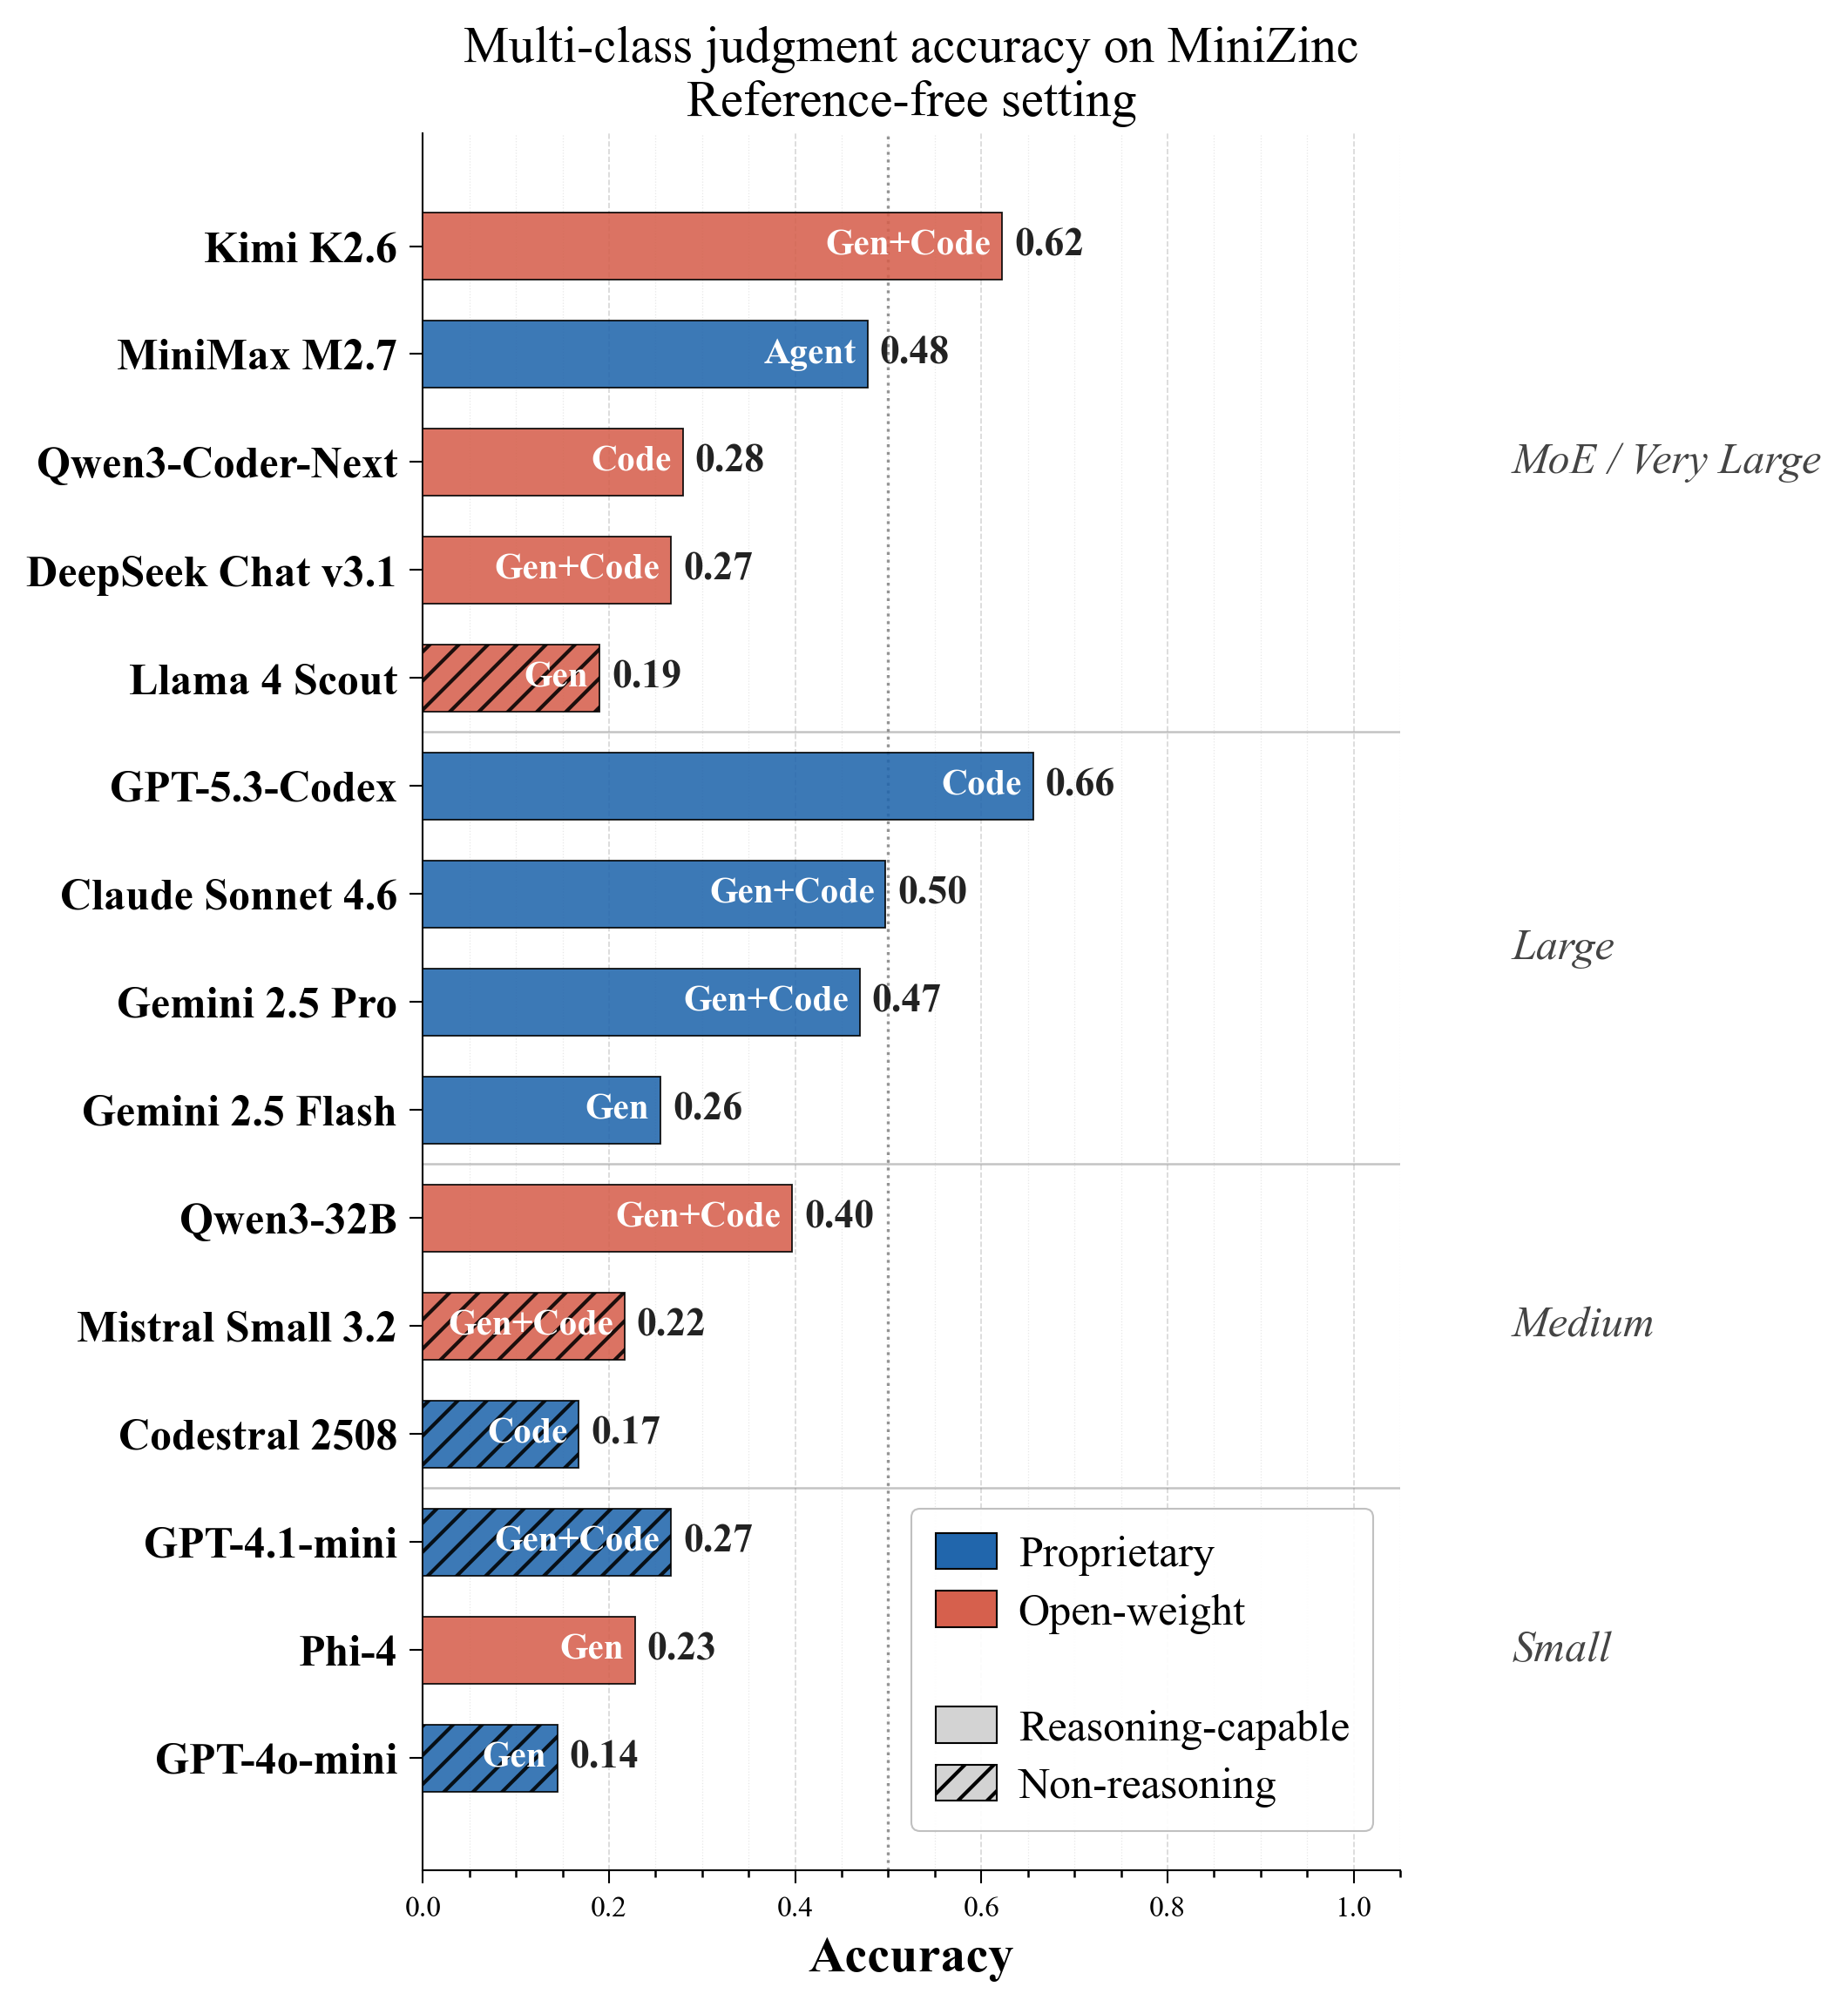

        short_name       size_group provider_type         reasoning  succeed  total  accuracy
      GPT-4.1-mini            Small   Proprietary     Non-reasoning       48    180  0.266667
             Phi-4            Small   Open-weight Reasoning-capable       41    180  0.227778
       GPT-4o-mini            Small   Proprietary     Non-reasoning       26    180  0.144444
         Qwen3-32B           Medium   Open-weight Reasoning-capable       71    179  0.396648
 Mistral Small 3.2           Medium   Open-weight     Non-reasoning       39    180  0.216667
    Codestral 2508           Medium   Proprietary     Non-reasoning       30    179  0.167598
     GPT-5.3-Codex            Large   Proprietary Reasoning-capable      118    180  0.655556
 Claude Sonnet 4.6            Large   Proprietary Reasoning-capable       89    179  0.497207
    Gemini 2.5 Pro            Large   Proprietary Reasoning-capable       84    179  0.469274
  Gemini 2.5 Flash            Large   Proprietary Reasoning-

In [72]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator


matplotlib.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size":         8.5,
    "axes.titlesize":    9,
    "axes.labelsize":    8.5,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   7.5,
    "legend.title_fontsize": 7.5,
    "figure.dpi":        300,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
})

# ── Load ───────────────────────────────────────────────────────────────────
judges = pd.read_csv("logs/judge-status-all.csv", dtype=str).fillna("")

# ── Judge metadata ─────────────────────────────────────────────────────────
JUDGE_INFO = {
    "openai/gpt-4o-mini":                      {"provider_type": "Proprietary", "orientation": "General",          "reasoning": "Non-reasoning",     "size_group": "Small",           "size_rank": 1, "short_name": "GPT-4o-mini"},
    "openai/gpt-4.1-mini":                     {"provider_type": "Proprietary", "orientation": "General / Coding", "reasoning": "Non-reasoning",     "size_group": "Small",           "size_rank": 1, "short_name": "GPT-4.1-mini"},
    "microsoft/phi-4":                         {"provider_type": "Open-weight", "orientation": "General",          "reasoning": "Reasoning-capable", "size_group": "Small",           "size_rank": 1, "short_name": "Phi-4"},
    "mistralai/mistral-small-3.2-24b-instruct":{"provider_type": "Open-weight", "orientation": "General / Coding", "reasoning": "Non-reasoning",     "size_group": "Medium",          "size_rank": 2, "short_name": "Mistral Small 3.2"},
    "qwen/qwen3-32b":                          {"provider_type": "Open-weight", "orientation": "General / Coding", "reasoning": "Reasoning-capable", "size_group": "Medium",          "size_rank": 2, "short_name": "Qwen3-32B"},
    "mistralai/codestral-2508":                {"provider_type": "Proprietary", "orientation": "Code",             "reasoning": "Non-reasoning",     "size_group": "Medium",          "size_rank": 2, "short_name": "Codestral 2508"},
    "google/gemini-2.5-flash":                 {"provider_type": "Proprietary", "orientation": "General",          "reasoning": "Reasoning-capable", "size_group": "Large",           "size_rank": 3, "short_name": "Gemini 2.5 Flash"},
    "anthropic/claude-sonnet-4.6":             {"provider_type": "Proprietary", "orientation": "General / Coding", "reasoning": "Reasoning-capable", "size_group": "Large",           "size_rank": 3, "short_name": "Claude Sonnet 4.6"},
    "google/gemini-2.5-pro":                   {"provider_type": "Proprietary", "orientation": "General / Coding", "reasoning": "Reasoning-capable", "size_group": "Large",           "size_rank": 3, "short_name": "Gemini 2.5 Pro"},
    "openai/gpt-5.3-codex":                    {"provider_type": "Proprietary", "orientation": "Code",             "reasoning": "Reasoning-capable", "size_group": "Large",           "size_rank": 3, "short_name": "GPT-5.3-Codex"},
    "meta-llama/llama-4-scout":                {"provider_type": "Open-weight", "orientation": "General",          "reasoning": "Non-reasoning",     "size_group": "MoE / Very Large","size_rank": 4, "short_name": "Llama 4 Scout"},
    "deepseek/deepseek-chat-v3.1":             {"provider_type": "Open-weight", "orientation": "General / Coding", "reasoning": "Reasoning-capable", "size_group": "MoE / Very Large","size_rank": 4, "short_name": "DeepSeek Chat v3.1"},
    "qwen/qwen3-coder-next":                   {"provider_type": "Open-weight", "orientation": "Code",             "reasoning": "Reasoning-capable", "size_group": "MoE / Very Large","size_rank": 4, "short_name": "Qwen3-Coder-Next"},
    "minimax/minimax-m2.7":                    {"provider_type": "Proprietary", "orientation": "Agentic",          "reasoning": "Reasoning-capable", "size_group": "MoE / Very Large","size_rank": 4, "short_name": "MiniMax M2.7"},
    "moonshotai/kimi-k2.6":                    {"provider_type": "Open-weight", "orientation": "General / Coding", "reasoning": "Reasoning-capable", "size_group": "MoE / Very Large","size_rank": 4, "short_name": "Kimi K2.6"},
    # "z-ai/glm-4.5-air":                        {"provider_type": "Open-weight", "orientation": "General",          "reasoning": "Reasoning-capable", "size_group": "MoE / Very Large","size_rank": 4, "short_name": "GLM-4.5-Air"},
}

JUDGE_MODELS = list(JUDGE_INFO.keys())

# ── Filter ─────────────────────────────────────────────────────────────────
language = "minizinc"
approach = "reference_free"

sub = judges[
    (judges["language"] == language) &
    (judges["approach"] == approach) &
    (judges["judgment"] != "judge-error") &
    (judges["judge_llm"].isin(JUDGE_MODELS))
].copy()

sub["succeed_flag"] = (sub["succeed"] == "yes").astype(int)

# ── Aggregate ──────────────────────────────────────────────────────────────
agg = sub.groupby("judge_llm", as_index=False).agg(
    total=("succeed_flag", "count"),
    succeed=("succeed_flag", "sum"),
)
agg["accuracy"] = agg["succeed"] / agg["total"]

meta = pd.DataFrame.from_dict(JUDGE_INFO, orient="index").reset_index().rename(columns={"index": "judge_llm"})
agg = agg.merge(meta, on="judge_llm", how="left")
agg = agg.sort_values(["size_rank", "accuracy"], ascending=[True, True]).reset_index(drop=True)

# ── Visual encodings ───────────────────────────────────────────────────────
PROP_COLOR  = "#2166AC"
OPEN_COLOR  = "#D6604D"
HATCH       = {"Reasoning-capable": "", "Non-reasoning": "///"}
ORIENT_ABBR = {"General": "Gen", "General / Coding": "Gen+Code", "Code": "Code", "Agentic": "Agent"}

bar_colors  = [PROP_COLOR if p == "Proprietary" else OPEN_COLOR for p in agg["provider_type"]]
bar_hatches = [HATCH[r] for r in agg["reasoning"]]

# ── Plot ───────────────────────────────────────────────────────────────────
n = len(agg)
fig, ax = plt.subplots(figsize=(7.2, 0.40 * n + 1.6))

bars = ax.barh(range(n), agg["accuracy"], height=0.62,
               color=bar_colors, edgecolor="black", linewidth=0.45, alpha=0.88, zorder=3)
for bar, hatch in zip(bars, bar_hatches):
    bar.set_hatch(hatch)

# Orientation label inside bar
for i, (a, ori) in enumerate(zip(agg["accuracy"], agg["orientation"])):
    abbr = ORIENT_ABBR.get(ori, ori)
    if a > 0.12:
        ax.text(a - 0.012, i, abbr, va="center", ha="right",
                fontsize=10, color="white", fontweight="bold", zorder=5)

# Accuracy + counts after bar
for i, row in agg.iterrows():
    ax.text(
        row["accuracy"] + 0.013, i,
        f"{row['accuracy']:.2f}",
        # ({int(row['succeed'])}/{int(row['total'])})
        va="center", ha="left", fontsize=11, color="#222222", zorder=4,  fontweight="bold",
    )

# Axes
ax.set_yticks(range(n))
ax.set_yticklabels(agg["short_name"], fontsize=12, fontweight="bold",)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Accuracy", labelpad=4, fontsize=14,  fontweight="bold",)
ax.xaxis.set_major_locator(MultipleLocator(0.2))
ax.xaxis.set_minor_locator(MultipleLocator(0.05))
ax.grid(axis="x", which="major", linestyle="--", linewidth=0.4, alpha=0.5, zorder=0)
ax.grid(axis="x", which="minor", linestyle=":",  linewidth=0.3, alpha=0.3, zorder=0)
ax.set_axisbelow(True)

# Chance baseline
ax.axvline(0.5, color="dimgray", linewidth=0.8, linestyle=":", zorder=2, alpha=0.7)
# ax.text(0.5 + 0.008, -0.85, "Chance", fontsize=6.5, color="dimgray", va="top")

# Group separators + size-group labels
group_spans = {}
for i, (rank, grp) in enumerate(zip(agg["size_rank"], agg["size_group"])):
    if rank not in group_spans:
        group_spans[rank] = [i, i, grp]
    else:
        group_spans[rank][1] = i

for rank, (start, end, grp) in sorted(group_spans.items()):
    if start > 0:
        ax.axhline(start - 0.5, color="#888888", linewidth=0.6, linestyle="-", alpha=0.5, zorder=2)
    ax.text(1.115, (start + end) / 2, grp, va="center", ha="left",
            fontsize=12, fontstyle="italic", color="#444444",
            transform=ax.get_yaxis_transform())

# Legend
leg_handles = [
    mpatches.Patch(facecolor=PROP_COLOR, edgecolor="black", linewidth=0.5, label="Proprietary"),
    mpatches.Patch(facecolor=OPEN_COLOR,  edgecolor="black", linewidth=0.5, label="Open-weight"),
    mpatches.Patch(facecolor="none",      edgecolor="none",                 label=""),
    mpatches.Patch(facecolor="lightgray", edgecolor="black", linewidth=0.5, label="Reasoning-capable"),
    mpatches.Patch(facecolor="lightgray", edgecolor="black", linewidth=0.5, hatch="///", label="Non-reasoning"),
]
leg = ax.legend(handles=leg_handles, loc="lower right", bbox_to_anchor=(0.995, 0.01),
                frameon=True, framealpha=0.92, edgecolor="#bbbbbb",
                handlelength=1.4, handleheight=0.9, handletextpad=0.5,
                labelspacing=0.35, borderpad=0.55, fontsize=12)
leg.get_frame().set_linewidth(0.5)

# Title & spines
ax.set_title(
    "Multi-class judgment accuracy on MiniZinc\nReference-free setting",
    fontsize=14,
    pad=5
)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

plt.tight_layout(pad=0.5)
plt.savefig("judge_accuracy_minizinc_reference_free.pdf", bbox_inches="tight")
# plt.savefig("judge_accuracy_minizinc_reference_free.png", bbox_inches="tight", dpi=300)
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────
print(
    agg.sort_values(["size_rank", "accuracy"], ascending=[True, False])[
        ["short_name", "size_group", "provider_type", "reasoning",
         "succeed", "total", "accuracy"]
    ].to_string(index=False)
)